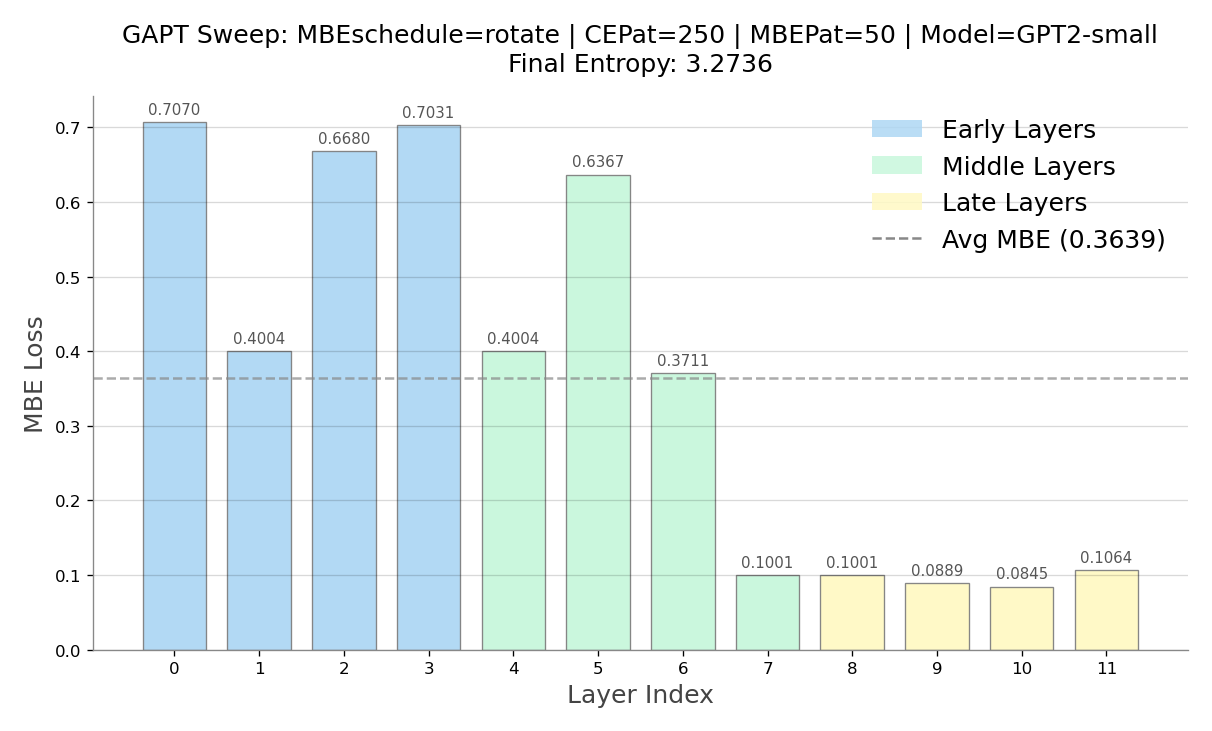

In [38]:
# Analysis on log runs 
from src.utils import *

# ----- IBLM ----- 
log_path = "logs/iblm3.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])

# --- visualize dynamics ---
frames = []
for i in range(len(loss_record["entropy"])):
    if i % 1 == 0: # Optional: skip frames for speed
        print(f"Rendering frame {i}/{len(loss_record['entropy'])}", end='\r')
        frames.append(create_training_frame(i, loss_record, run_info=run_info, n_layer=n_layer))

frames[0].save(
    f"mbe_dynamics_{run_info}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100, # ms per frame
    loop=0
)

# --- visualize final losses ---
visualize_final_losses(loss_record, run_info=run_info, n_layer=n_layer)

In [ ]:
# Issue #1. Rotation adopts 'skip_last=1'

[10.8258695602417,
 4.444347381591797,
 4.0197882652282715,
 3.8406713008880615,
 3.7178521156311035,
 3.639683961868286,
 3.5829315185546875,
 3.5413625240325928,
 3.5004093647003174,
 3.465099811553955,
 3.4128880500793457,
 3.36932110786438,
 3.335347890853882,
 3.3008644580841064,
 3.273577928543091]

In [33]:
from sorl.stat import extract_log_data

# ----- SoRL ----- 
log_path = "logs/k-curr20.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])
if "attn sweep" not in run_info:
    run_info += " + attn_sweep" 

# --- visualize dynamics --- 
# (1). x-axis: step, y-axis: search info gain, util rate, search adv, cond_traj_loss, base_traj_loss 
#     group some of them together (cond_traj_loss, base_traj_loss) (search info gain, search adv), util rate
#     3 rows 1 column, make a gif plot out


In [34]:
from sorl.stat import generate_sorl_dynamics_gif

generate_sorl_dynamics_gif(loss_record, "logs/k_curriculum_dynamics.gif", run_info, val_interval=125, fps=5)

Fixed axis limits: {'loss_min': 0.9808749999999999, 'loss_max': 11.370450000000002, 'adv_min': -0.00499983314, 'adv_max': 0.027200000000000002, 'info_min': -0.023899999999999998, 'info_max': 0.0365}
Generated frame 10/29
Generated frame 20/29
GIF saved to: logs/k_curriculum_dynamics.gif


In [32]:
run_info

'Ablation: Abstract Vocab Size=128, Iter=1750, AlphaInfo=10.0 (TinyStories) + attn_sweep'